# Exploratory Data Analysis - Security Logs

This notebook explores the cybersecurity dataset before building the main application.
The project uses **Pandas** for data loading and analysis, **Numpy** for numerical calculations,
and **Matplotlib** for visualizations.

Dataset source: https://www.kaggle.com/datasets/aryan208/cybersecurity-threat-detection-logs

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load the dataset

In [4]:
df = pd.read_csv("../data/logs.csv", parse_dates=["timestamp"])
df.shape

(6000000, 10)

In [5]:
df.head()

,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login
3,2024-10-26,192.168.1.236,192.168.1.219,HTTP,allowed,benign,application,5350,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,/login
4,2024-10-31,192.168.1.221,192.168.1.61,ICMP,allowed,benign,application,40691,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   source_ip          object        
 2   dest_ip            object        
 3   protocol           object        
 4   action             object        
 5   threat_label       object        
 6   log_type           object        
 7   bytes_transferred  int64         
 8   user_agent         object        
 9   request_path       object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 457.8+ MB


In [7]:
df.describe()

,timestamp,bytes_transferred
count,6000000,6.000000e+06
mean,2024-07-01 00:13:39.417600,2.504649e+04
min,2024-01-01 00:00:00,1.000000e+02
25%,2024-04-01 00:00:00,1.258400e+04
50%,2024-07-01 00:00:00,2.503600e+04
75%,2024-09-30 00:00:00,3.751900e+04
max,2024-12-30 00:00:00,5.000000e+04
std,NaN,1.440163e+04


## Threat label distribution

The dataset classifies each log entry as `benign`, `suspicious`, or `malicious`.

In [8]:
label_counts = df["threat_label"].value_counts()
label_counts

threat_label
benign        5517611
suspicious     360883
malicious      121506
Name: count, dtype: int64

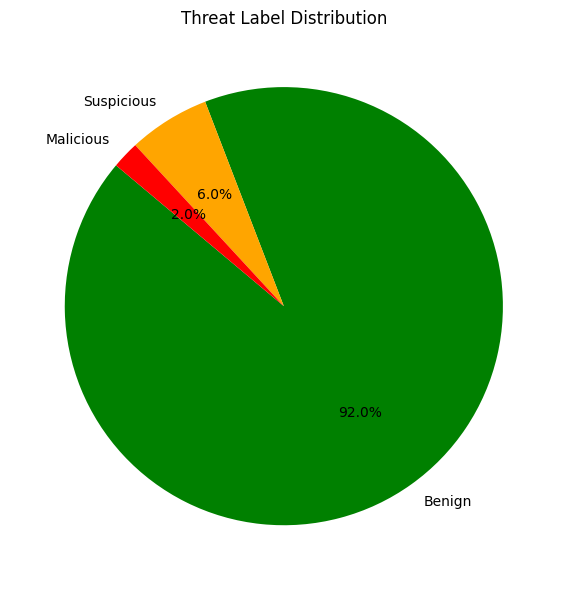

In [9]:
colors = ["green", "orange", "red"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    label_counts.values,
    labels=[lbl.capitalize() for lbl in label_counts.index],
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
)
ax.set_title("Threat Label Distribution")
plt.tight_layout()
plt.show()

## Bytes transferred - Numpy analysis

Convert the column to a Numpy array and calculate basic statistics.

In [10]:
bytes_arr = df["bytes_transferred"].to_numpy()

print(f"Mean:   {np.mean(bytes_arr):,.0f} B")
print(f"Median: {np.median(bytes_arr):,.0f} B")
print(f"Std:    {np.std(bytes_arr):,.0f} B")
print(f"Min:    {np.min(bytes_arr):,} B")
print(f"Max:    {np.max(bytes_arr):,} B")

Mean:   25,046 B
Median: 25,036 B
Std:    14,402 B
Min:    100 B
Max:    50,000 B


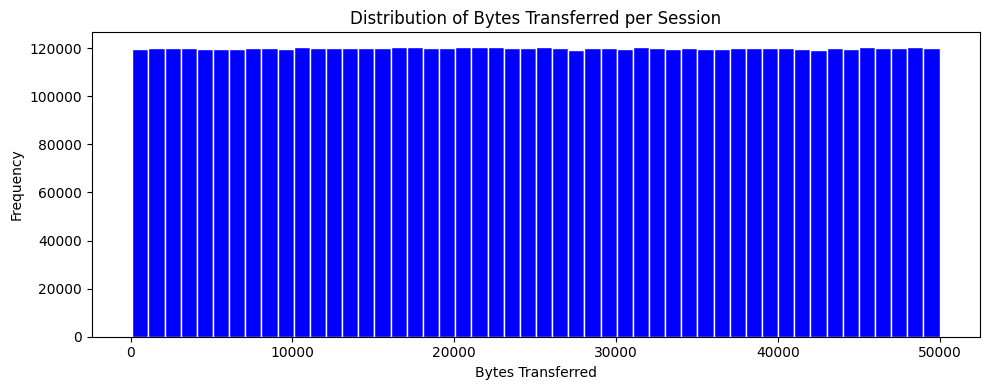

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bytes_arr, bins=50, color="blue", edgecolor="white")
ax.set_xlabel("Bytes Transferred")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Bytes Transferred per Session")
plt.tight_layout()
plt.show()

## Top source IPs

Which IP addresses appear most frequently in the logs?

In [12]:
top_ips = df["source_ip"].value_counts().head(10)
top_ips

source_ip
59.211.9.207       18295
109.106.120.222    18273
88.72.40.56        18252
185.225.185.68     18239
122.63.201.122     18229
229.140.23.152     18203
44.137.187.63      18202
61.72.172.125      18193
114.207.221.220    18193
166.19.156.163     18178
Name: count, dtype: int64

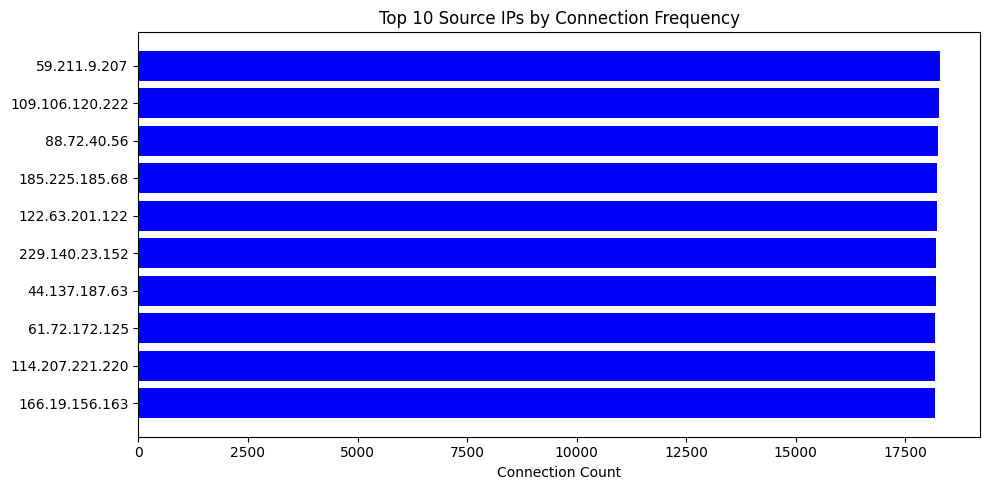

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_ips.index[::-1], top_ips.values[::-1], color="blue")
ax.set_xlabel("Connection Count")
ax.set_title("Top 10 Source IPs by Connection Frequency")
plt.tight_layout()
plt.show()

## Activity over time

How does network activity vary across the year? `resample()` to aggregate by day.

In [14]:
daily = df.set_index("timestamp").resample("D").size()
daily.head()

timestamp
2024-01-01    16630
2024-01-02    16311
2024-01-03    16143
2024-01-04    16336
2024-01-05    16507
Freq: D, dtype: int64

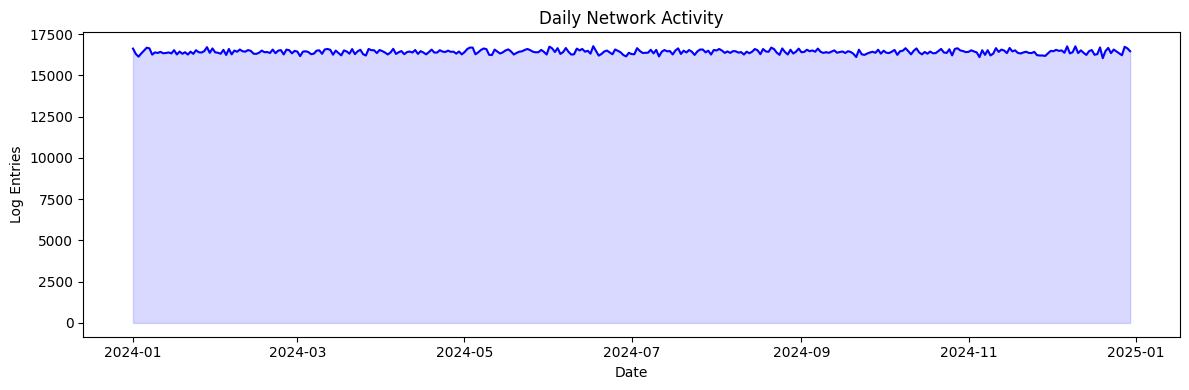

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color="blue", linewidth=1.5)
ax.fill_between(daily.index, daily.values, alpha=0.15, color="blue")
ax.set_xlabel("Date")
ax.set_ylabel("Log Entries")
ax.set_title("Daily Network Activity")
plt.tight_layout()
plt.show()

## Bytes transferred per threat label

Does malicious traffic use more bandwidth than benign traffic?

In [16]:
grouped = df.groupby("threat_label")["bytes_transferred"].agg(["mean", "max", "sum"])
grouped

,mean,max,sum
threat_label,,,
benign,25046.734187,50000,138198136066
malicious,25016.111287,50000,3039607618
suspicious,25053.021733,50000,9041209642


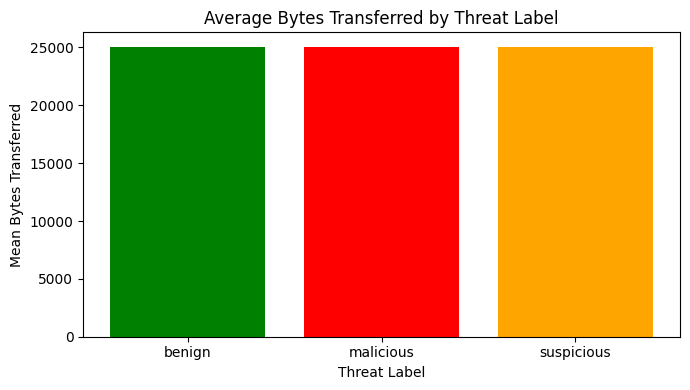

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(grouped.index, grouped["mean"], color=["green", "red", "orange"])
ax.set_xlabel("Threat Label")
ax.set_ylabel("Mean Bytes Transferred")
ax.set_title("Average Bytes Transferred by Threat Label")
plt.tight_layout()
plt.show()